In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
df['ChurnFlag'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
df[['Churn', 'ChurnFlag']].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

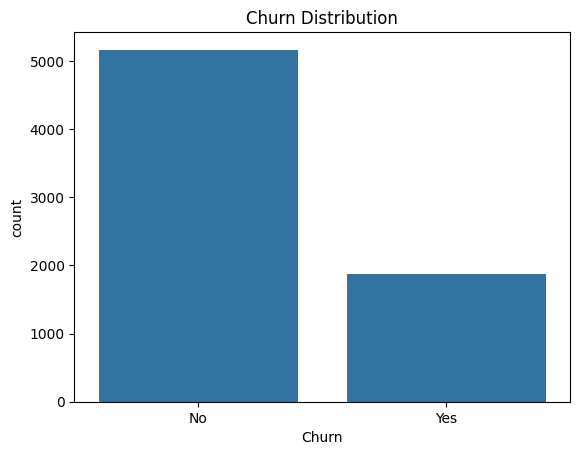

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

In [ ]:
df['ChurnFlag'].mean() * 100

np.float64(26.578498293515356)

In [ ]:
df.groupby('Contract')['ChurnFlag'].mean() * 100

,ChurnFlag
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


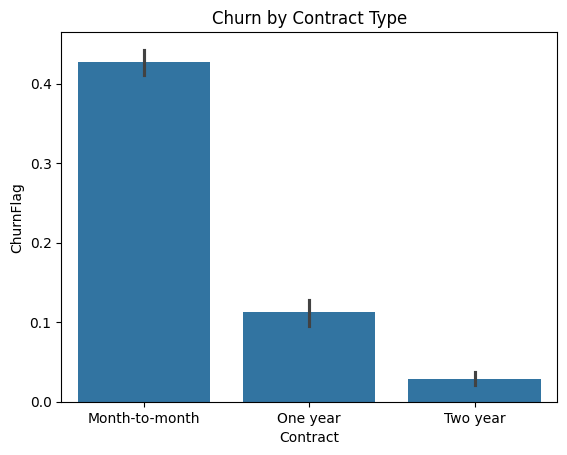

In [ ]:
sns.barplot(
    x='Contract',
    y='ChurnFlag',
    data=df
)

plt.title('Churn by Contract Type')

plt.show()

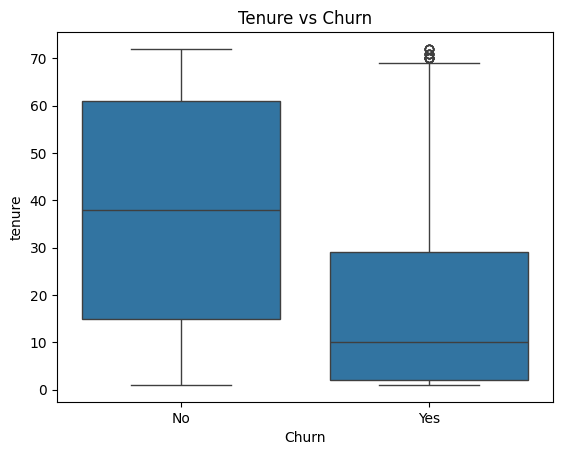

In [ ]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure vs Churn')

plt.show()

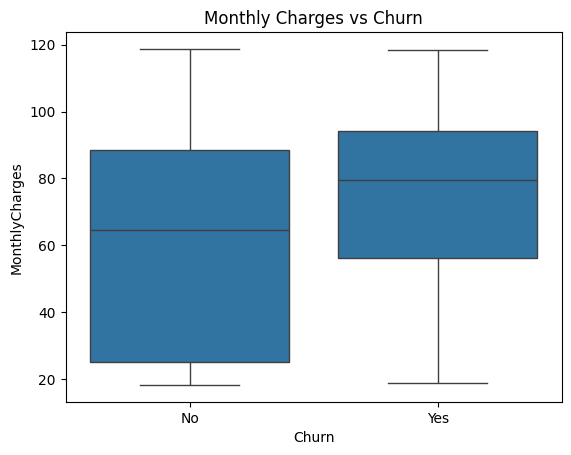

In [ ]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Churn')

plt.show()

In [ ]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-12 Months',
        '12-24 Months',
        '24-48 Months',
        '48-72 Months'
    ]
)

In [ ]:
df.groupby('TenureGroup')['ChurnFlag'].mean() * 100

/tmp/ipykernel_856/621786827.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('TenureGroup')['ChurnFlag'].mean() * 100


,ChurnFlag
TenureGroup,
0-12 Months,47.678161
12-24 Months,28.710938
24-48 Months,20.388959
48-72 Months,9.513176


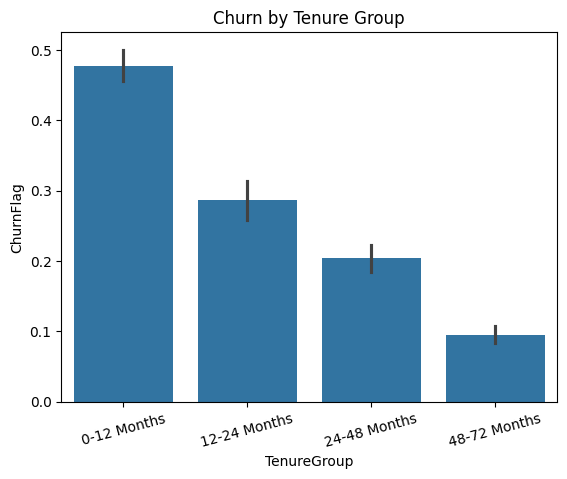

In [ ]:
sns.barplot(
    x='TenureGroup',
    y='ChurnFlag',
    data=df
)

plt.title('Churn by Tenure Group')

plt.xticks(rotation=15)

plt.show()

In [ ]:
df[df['Churn']=='Yes']['MonthlyCharges'].sum()

np.float64(139130.85)

In [ ]:
service_cols = [
    'PhoneService',
    'OnlineSecurity',
    'StreamingTV'
]

df['TotalServices'] = (
    df[service_cols] == 'Yes'
).sum(axis=1)

In [ ]:
df.groupby('TotalServices')['ChurnFlag'].mean()

,ChurnFlag
TotalServices,
0,0.367089
1,0.260377
2,0.306804
3,0.152432


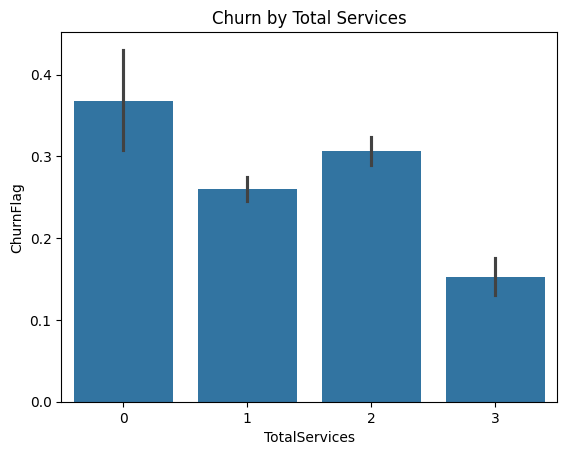

In [ ]:
sns.barplot(
    x='TotalServices',
    y='ChurnFlag',
    data=df
)

plt.title('Churn by Total Services')

plt.show()

In [ ]:
df.groupby('PaymentMethod')['ChurnFlag'].mean() * 100

,ChurnFlag
PaymentMethod,
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123
Electronic check,45.285412
Mailed check,19.201995


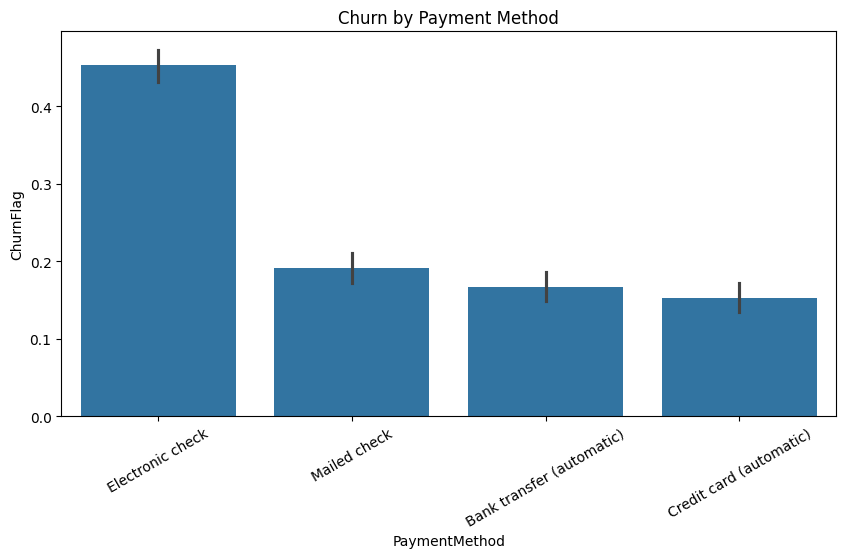

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='PaymentMethod',
    y='ChurnFlag',
    data=df
)

plt.xticks(rotation=30)

plt.title('Churn by Payment Method')

plt.show()

In [ ]:
df.groupby('InternetService')['ChurnFlag'].mean() * 100

,ChurnFlag
InternetService,
DSL,18.998344
Fiber optic,41.892765
No,7.434211


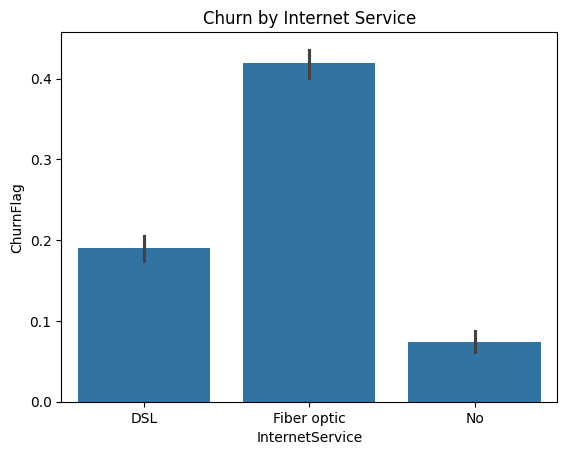

In [ ]:
sns.barplot(
    x='InternetService',
    y='ChurnFlag',
    data=df
)

plt.title('Churn by Internet Service')

plt.show()

In [ ]:
df.groupby('SeniorCitizen')['ChurnFlag'].mean() * 100

,ChurnFlag
SeniorCitizen,
0,23.650255
1,41.681261


In [ ]:
numeric_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'ChurnFlag',
    'TotalServices'
]

corr = df[numeric_cols].corr()

corr

,tenure,MonthlyCharges,TotalCharges,ChurnFlag,TotalServices
tenure,1.000000,0.246862,0.825880,-0.354049,0.378625
MonthlyCharges,0.246862,1.000000,0.651065,0.192858,0.677389
TotalCharges,0.825880,0.651065,1.000000,-0.199484,0.620925
ChurnFlag,-0.354049,0.192858,-0.199484,1.000000,-0.056990
TotalServices,0.378625,0.677389,0.620925,-0.056990,1.000000


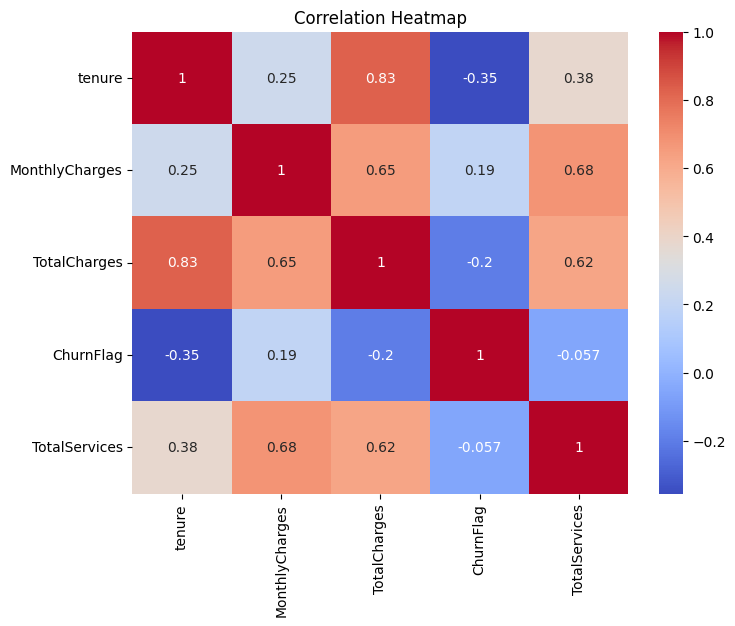

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
df['RevenuePerMonth'] = (
    df['TotalCharges'] / (df['tenure'] + 1)
)

In [ ]:
def risk_segment(row):

    if row['tenure'] < 12 and row['MonthlyCharges'] > 70:
        return 'High Risk'

    elif row['tenure'] > 48:
        return 'Loyal'

    return 'Medium Risk'

In [ ]:
df['RiskSegment'] = df.apply(
    risk_segment,
    axis=1
)

In [ ]:
df.groupby('RiskSegment')['ChurnFlag'].mean() * 100

,ChurnFlag
RiskSegment,
High Risk,68.810680
Loyal,9.513176
Medium Risk,27.437642


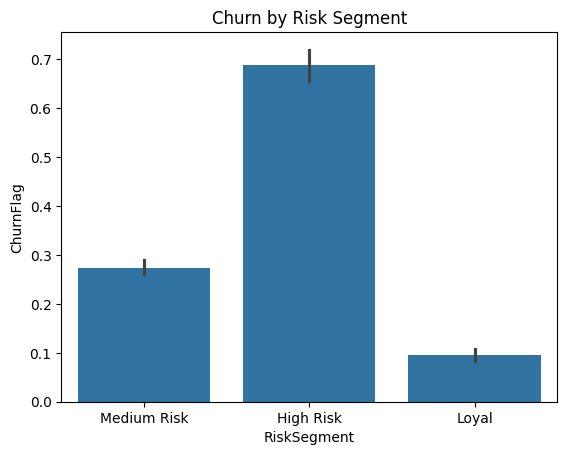

In [ ]:
sns.barplot(
    x='RiskSegment',
    y='ChurnFlag',
    data=df
)

plt.title('Churn by Risk Segment')

plt.show()

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,TenureGroup,TotalServices,RevenuePerMonth,RiskSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0,0-12 Months,0,14.925000,Medium Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,0,24-48 Months,2,53.985714,Medium Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,1,0-12 Months,2,36.050000,Medium Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,0,24-48 Months,1,40.016304,Medium Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,1,0-12 Months,1,50.550000,High Risk


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df = df.drop(columns=['customerID'])

In [ ]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [ ]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnFlag,TotalServices,RevenuePerMonth,gender_Male,Partner_Yes,Dependents_Yes,...,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,TenureGroup_12-24 Months,TenureGroup_24-48 Months,TenureGroup_48-72 Months,RiskSegment_Loyal,RiskSegment_Medium Risk
0,0,1,29.85,29.85,0,0,14.925000,False,True,False,...,True,False,True,False,False,False,False,False,False,True
1,0,34,56.95,1889.50,0,2,53.985714,True,False,False,...,False,False,False,True,False,False,True,False,False,True
2,0,2,53.85,108.15,1,2,36.050000,True,False,False,...,True,False,False,True,True,False,False,False,False,True
3,0,45,42.30,1840.75,0,1,40.016304,True,False,False,...,False,False,False,False,False,False,True,False,False,True
4,0,2,70.70,151.65,1,1,50.550000,False,False,False,...,True,False,True,False,True,False,False,False,False,False


In [ ]:
X = df_encoded.drop(columns=['ChurnFlag'])

y = df_encoded['ChurnFlag']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(
    max_iter=1000
)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
preds = model.predict(X_test)

In [ ]:
probs = model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1033
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1407
   macro avg       1.00      1.00      1.00      1407
weighted avg       1.00      1.00      1.00      1407



In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, probs)

np.float64(1.0)

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

In [ ]:
importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
32,Churn_Yes,10.537084
12,InternetService_Fiber optic,0.840697
25,StreamingMovies_Yes,0.359875
23,StreamingTV_Yes,0.320178
11,MultipleLines_Yes,0.216725
0,SeniorCitizen,0.186313
33,TenureGroup_12-24 Months,0.162749
28,PaperlessBilling_Yes,0.154378
34,TenureGroup_24-48 Months,0.122831
30,PaymentMethod_Electronic check,0.121760


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    eval_metric='logloss'
)

In [ ]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_preds = xgb.predict(X_test)

xgb_probs = xgb.predict_proba(X_test)[:,1]

In [ ]:
print(
    classification_report(
        y_test,
        xgb_preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1033
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1407
   macro avg       1.00      1.00      1.00      1407
weighted avg       1.00      1.00      1.00      1407



In [ ]:
roc_auc_score(y_test, xgb_probs)

np.float64(1.0)

In [ ]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

In [ ]:
xgb_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
32,Churn_Yes,1.0
0,SeniorCitizen,0.0
2,MonthlyCharges,0.0
3,TotalCharges,0.0
4,TotalServices,0.0
1,tenure,0.0
5,RevenuePerMonth,0.0
6,gender_Male,0.0
8,Dependents_Yes,0.0
7,Partner_Yes,0.0


In [ ]:
df_encoded['ChurnProbability'] = xgb.predict_proba(X)[:,1]

In [ ]:
def risk_level(prob):

    if prob >= 0.8:
        return 'High Risk'

    elif prob >= 0.5:
        return 'Medium Risk'

    return 'Low Risk'

In [ ]:
df_encoded['RiskLevel'] = (
    df_encoded['ChurnProbability']
    .apply(risk_level)
)

In [ ]:
df_encoded['RiskLevel'].value_counts()

,count
RiskLevel,
Low Risk,5163
High Risk,1869


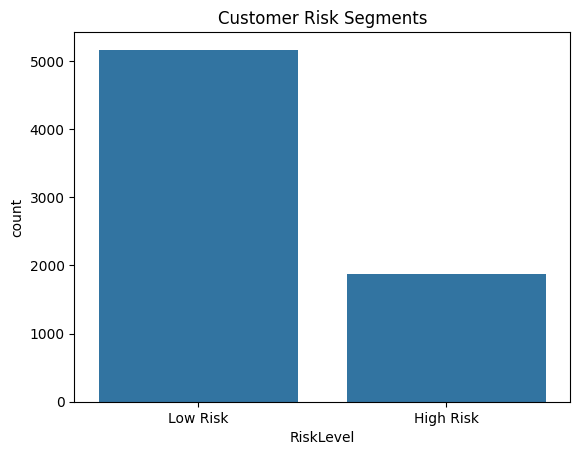

In [ ]:
sns.countplot(
    x='RiskLevel',
    data=df_encoded
)

plt.title('Customer Risk Segments')

plt.show()

In [ ]:
def retention_strategy(row):

    if (
        row['ChurnProbability'] > 0.8
        and row['MonthlyCharges'] > 70
    ):
        return 'Priority Retention Call'

    elif (
    row['Contract_One year'] == 0
    and row['Contract_Two year'] == 0
):
        return 'Offer Annual Contract Discount'

    elif row['tenure'] < 12:
        return 'Customer Onboarding Support'

    return 'Regular Engagement'

In [ ]:
df_encoded['RetentionAction'] = df_encoded.apply(
    retention_strategy,
    axis=1
)

In [ ]:
df_encoded[
    [
        'ChurnProbability',
        'RiskLevel',
        'RetentionAction'
    ]
].head()

,ChurnProbability,RiskLevel,RetentionAction
0,0.000236,Low Risk,Offer Annual Contract Discount
1,0.000236,Low Risk,Regular Engagement
2,0.999347,High Risk,Offer Annual Contract Discount
3,0.000236,Low Risk,Regular Engagement
4,0.999347,High Risk,Priority Retention Call


In [ ]:
df_encoded['RetentionAction'].value_counts()

,count
RetentionAction,
Regular Engagement,2846
Offer Annual Contract Discount,2770
Priority Retention Call,1267
Customer Onboarding Support,149


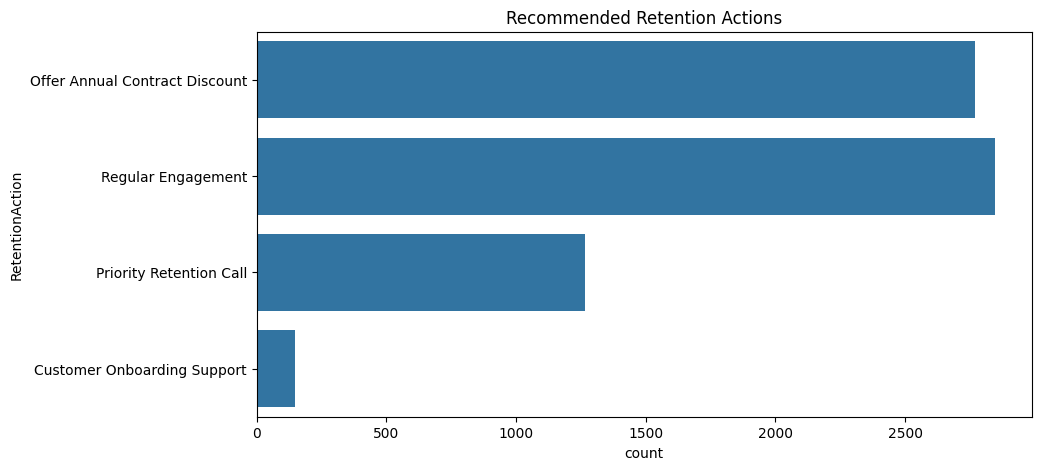

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='RetentionAction',
    data=df_encoded
)

plt.title('Recommended Retention Actions')

plt.show()

In [ ]:
dashboard_df = df_encoded.copy()

In [ ]:
dashboard_df.to_csv(
    'churn_dashboard.csv',
    index=False
)